# Job Pipeline Analysis

Exploratory analysis of scored jobs from the cyber-jobs-radar pipeline.

Data: `profiles/omer/all_scores.jsonl` — append-only log of every job scored, including failures (Gemini 503s show up as `scorer-error` flag with score=0).

In [1]:
import json
import pathlib
import collections
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Path works whether run from notebooks/ or repo root
data_candidates = [
    pathlib.Path("../profiles/omer/all_scores.jsonl"),
    pathlib.Path("profiles/omer/all_scores.jsonl"),
]
data_path = next(p for p in data_candidates if p.exists())

rows = []
bad_lines = 0
for line in data_path.read_text(encoding="utf-8").splitlines():
    line = line.strip()
    if not line:
        continue
    try:
        rows.append(json.loads(line))
    except json.JSONDecodeError:
        bad_lines += 1
if bad_lines:
    print(f"Note: {bad_lines} malformed JSONL lines skipped.")
df = pd.DataFrame(rows)
if "flags" not in df.columns:
    df["flags"] = [[] for _ in range(len(df))]
df["flags"] = df["flags"].apply(lambda f: f if isinstance(f, list) else [])

df_clean = df[~df["flags"].apply(lambda f: "scorer-error" in f)].copy()
df_clean["score"] = pd.to_numeric(df_clean["score"], errors="coerce")
df_clean["vc_tier"] = pd.to_numeric(df_clean.get("vc_tier", pd.Series([None] * len(df_clean))), errors="coerce")

print(f"Total rows loaded:           {len(df)}")
print(f"Scorer-error rows (dropped): {len(df) - len(df_clean)}")
print(f"Clean rows for analysis:     {len(df_clean)}")
print(
    f"Score range:                 "
    f"{df_clean['score'].min():.0f}-{df_clean['score'].max():.0f}  "
    f"mean={df_clean['score'].mean():.1f}  median={df_clean['score'].median():.0f}"
)

Note: 2 malformed JSONL lines skipped.
Total rows loaded:           543
Scorer-error rows (dropped): 96
Clean rows for analysis:     447
Score range:                 0-10  mean=4.6  median=5


## 1 — Pipeline coverage

In [2]:
print(f"Companies tracked: {df_clean['company'].nunique()}")
ats_seen = sorted(df_clean['ats'].dropna().unique())
print(f"ATS systems ({len(ats_seen)}): {ats_seen}")

tier_label = df_clean['vc_tier'].apply(lambda t: f'Tier {int(t)}' if pd.notna(t) else 'Manual / big-co')
print('\nJobs by VC tier:')
for label, count in tier_label.value_counts().sort_index().items():
    print(f'  {label:<20} {count}')

Companies tracked: 145
ATS systems (9): ['ashby', 'comeet', 'consider', 'getro', 'greenhouse', 'lever', 'teamtailor', 'workable', 'workday']

Jobs by VC tier:
  Manual / big-co      61
  Tier 1               47
  Tier 2               288
  Tier 3               51


## 2 — Score distribution

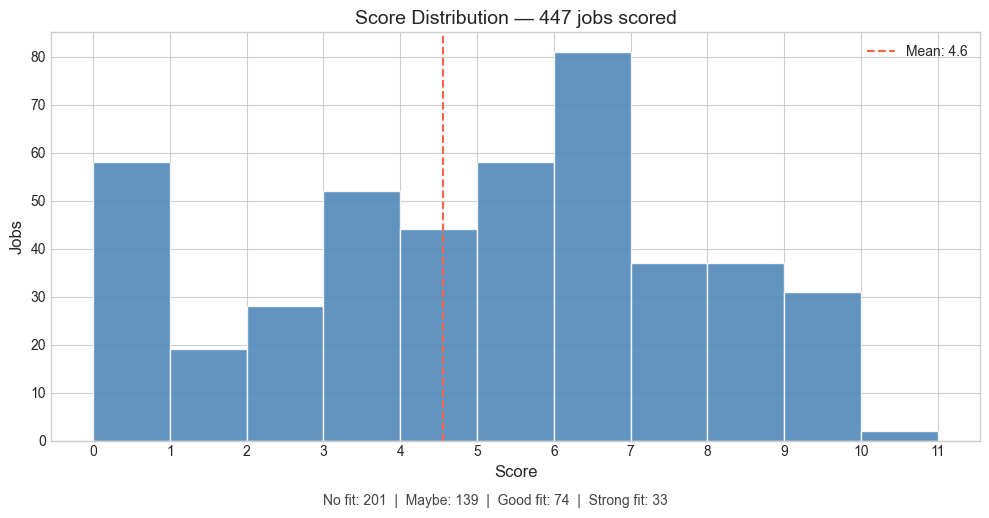

No fit: 201  |  Maybe: 139  |  Good fit: 74  |  Strong fit: 33


In [3]:
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    try:
        plt.style.use('ggplot')
    except Exception:
        pass

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean['score'].dropna(), bins=range(0, 12),
        edgecolor='white', color='steelblue', alpha=0.85)
mean_score = df_clean['score'].mean()
ax.axvline(mean_score, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Mean: {mean_score:.1f}')

tier_bands = [(0, 4, 'No fit'), (5, 6, 'Maybe'), (7, 8, 'Good fit'), (9, 10, 'Strong fit')]
band_text = '  |  '.join(
    f"{label}: {((df_clean['score'] >= lo) & (df_clean['score'] <= hi)).sum()}"
    for lo, hi, label in tier_bands
)
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Jobs', fontsize=12)
ax.set_title(f'Score Distribution — {len(df_clean)} jobs scored', fontsize=14)
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
fig.text(0.5, -0.02, band_text, ha='center', fontsize=10, color='#444')
plt.tight_layout()
plt.show()
print(band_text)

## 3 — Score by VC tier

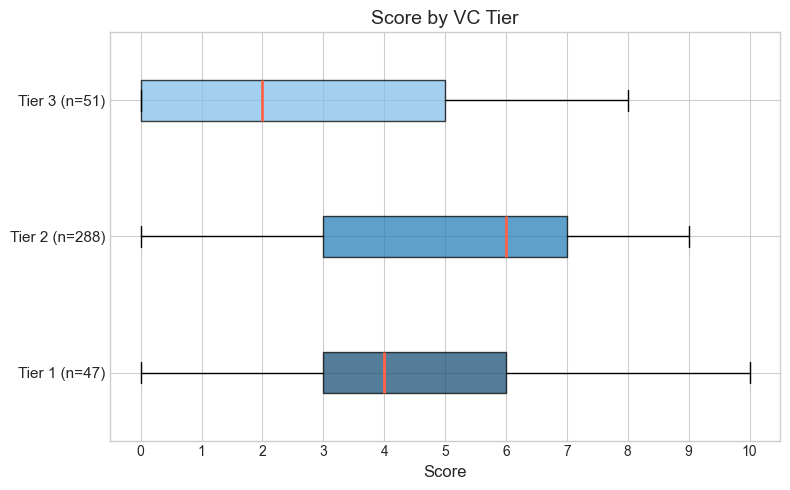

In [4]:
tier_df = df_clean.dropna(subset=['vc_tier', 'score']).copy()
tier_df['tier_label'] = tier_df['vc_tier'].apply(lambda t: f'Tier {int(t)}')

groups = {label: g['score'].values for label, g in tier_df.groupby('tier_label')}
labels = sorted(groups)
data = [groups[label] for label in labels]
labels_with_n = [f"{label} (n={len(d)})" for label, d in zip(labels, data)]

fig, ax = plt.subplots(figsize=(8, 5))
box = ax.boxplot(data, vert=False, patch_artist=True,
                 medianprops=dict(color='tomato', linewidth=2))
palette = ['#1a5276', '#2980b9', '#85c1e9']
for patch, color in zip(box['boxes'], palette[:len(box['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_yticklabels(labels_with_n, fontsize=11)
ax.set_xlabel('Score', fontsize=12)
ax.set_title('Score by VC Tier', fontsize=14)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

## 4 — Top companies by mean score

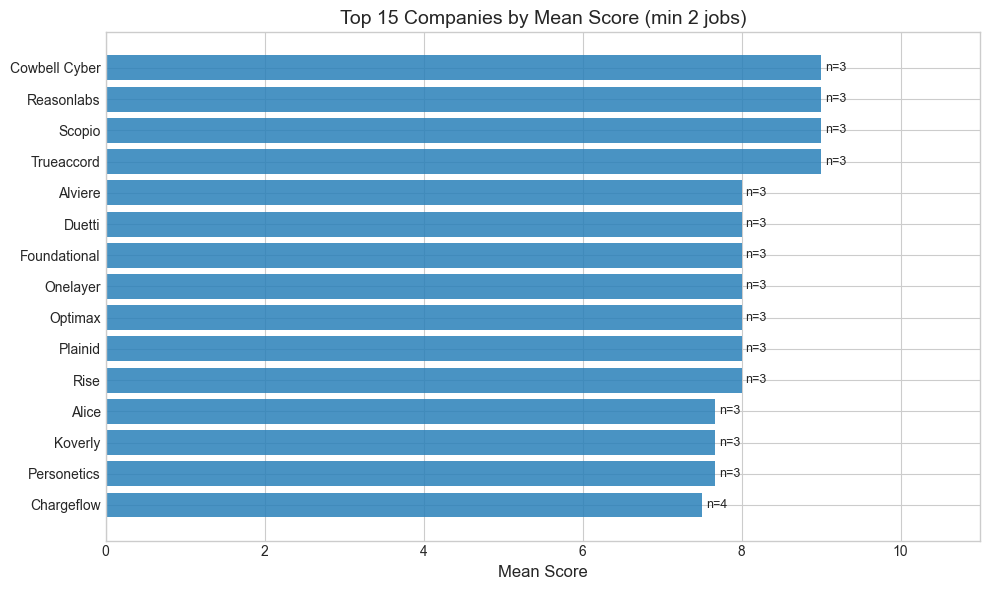

In [5]:
stats = (df_clean.groupby('company')
         .agg(mean_score=('score', 'mean'), n=('score', 'count'), vc_tier=('vc_tier', 'first'))
         .reset_index())
top = stats[stats['n'] >= 2].nlargest(15, 'mean_score')

cmap = {1.0: '#1a5276', 2.0: '#2980b9', 3.0: '#85c1e9'}
colors = [cmap.get(t, '#e07b39') for t in top['vc_tier']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top['company'], top['mean_score'], color=colors, alpha=0.85)
for bar, (_, row) in zip(bars, top.iterrows()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['n'])}", va='center', fontsize=9)
ax.set_xlabel('Mean Score', fontsize=12)
ax.set_title('Top 15 Companies by Mean Score (min 2 jobs)', fontsize=14)
ax.set_xlim(0, 11)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5 — Flag frequency

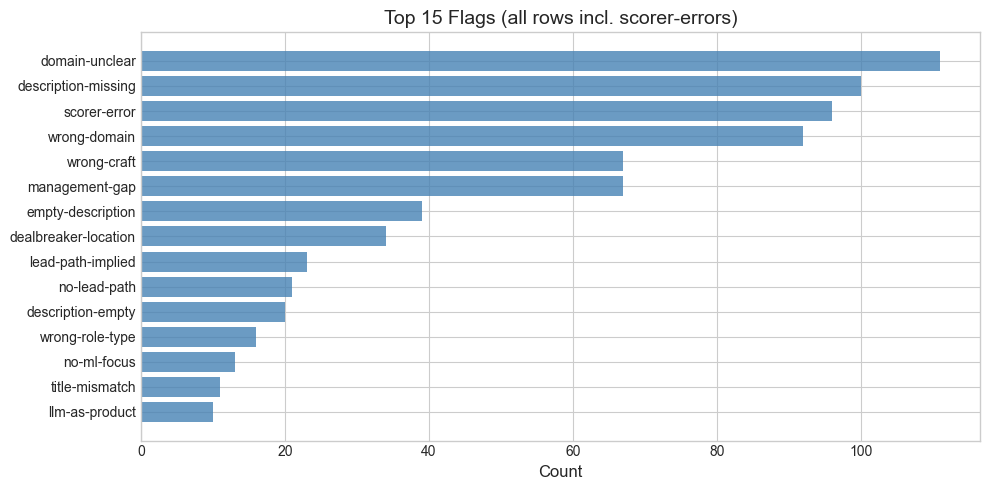

In [6]:
all_flags = [f for flags in df['flags'] for f in flags]
flag_counts = collections.Counter(all_flags).most_common(15)
labels_f = [f[0] for f in flag_counts][::-1]
vals_f = [f[1] for f in flag_counts][::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels_f, vals_f, color='steelblue', alpha=0.8)
ax.set_xlabel('Count', fontsize=12)
ax.set_title('Top 15 Flags (all rows incl. scorer-errors)', fontsize=14)
plt.tight_layout()
plt.show()

## 6 — Qualitative spot-check (tier 9-10)

In [7]:
top_tier = df_clean[df_clean['score'] >= 9]
if len(top_tier):
    sample = top_tier.sample(min(3, len(top_tier)), random_state=42)
    for _, row in sample.iterrows():
        print(f"Score {int(row['score'])} | {row['company']} — {row['title']}")
        print(f"  {str(row.get('reasoning', ''))[:200]}")
        print()
else:
    print("No tier 9-10 jobs in current dataset.")

Score 9 | Cowbell Cyber — Lead Data Scientist
  This Lead Data Scientist role at a cyber security company is a strong match for the candidate's primary target domain and desired leadership level.

Score 10 | Cognyte — AI Applications Team Leader
  An excellent match, combining a team lead role in cyber security with clear management responsibilities and production-grade AI applications, all within the desired location.

Score 9 | Reasonlabs — Team Lead Data Scientist
  The Team Lead Data Scientist title and Reasonlabs' cybersecurity domain are an excellent match for primary target roles, with location also fitting.

